In [1]:
import torch
import torch.autograd as autograd         
import torch.nn as nn                     
import torch.optim as optim               
import matplotlib.pyplot as plt
import numpy as np
import time


In [2]:

# --- Setup System Engine ---
torch.set_default_dtype(torch.float32)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: mps


In [3]:

# --- Set Consistent Domain Hyperparameters ---
layers = np.array([2, 64, 64, 64, 64, 1])
Nu = 400   
Nf = 10000 
steps=20000
lr=1e-3 # learning rate
#Nu: Number of training points # Nf: Number of collocation points (Evaluate PDE)
Nu=400 #known data point
Nf=10000 #collocation points
x_min, x_max = -1.0, 1.0
t_min, t_max = 0.0, 1.0
total_points_x = 200
total_points_t = 100


In [4]:

def f_real(x, t):
    return torch.exp(-t) * torch.sin(np.pi * x)


In [5]:

# --- PINN Neural Architecture ---
class FCN(nn.Module):
    def __init__(self, layers):
        super().__init__() 
        self.activation = nn.Tanh() 
        self.loss_function = nn.MSELoss(reduction='mean')
        self.linears = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)]) 
        self.iter = 0 
        
        for i in range(len(layers)-1):
            nn.init.xavier_normal_(self.linears[i].weight.data, gain=1.0)
            nn.init.zeros_(self.linears[i].bias.data)   
            
    def forward(self, x):
        if not torch.is_tensor(x):         
            x = torch.from_numpy(x)                
        a = x.float()
        for layer in self.linears[:-1]:  
            a = self.activation(layer(a))    
        return self.linears[-1](a)
        
    def lossBC(self, x_BC, y_BC):
        return self.loss_function(self.forward(x_BC), y_BC)
        
    def lossPDE(self, x_PDE):
        g = x_PDE.clone()
        g.requires_grad = True 
        f_pred = self.forward(g)
        
        # Calculate clean partial differential steps
        f_x_t = autograd.grad(f_pred, g, torch.ones([g.shape[0], 1]).to(device), retain_graph=True, create_graph=True)[0]
        f_xx_tt = autograd.grad(f_x_t, g, torch.ones(g.shape).to(device), create_graph=True)[0]
        
        x_coords = g[:, [0]]
        t_coords = g[:, [1]]
        
        f_t = f_x_t[:, [1]]   
        f_xx = f_xx_tt[:, [0]] 
        
        # Fully expanded layout matching your original PDE target formula
        source_term = torch.exp(-t_coords) * (torch.sin(np.pi * x_coords) - (np.pi ** 2) * torch.sin(np.pi * x_coords))
        f_residual = f_t - f_xx + source_term
        
        return self.loss_function(f_residual, torch.zeros_like(f_residual).to(device))

    def loss(self, x_BC, y_BC, x_PDE):
        return (20.0 * self.lossBC(x_BC, y_BC)) + self.lossPDE(x_PDE)

    def closure(self):
        optimizer.zero_grad()  
        loss = self.loss(X_train_Nu, Y_train_Nu, X_train_Nf)
        loss.backward()      
        self.iter += 1
        if self.iter % 100 == 0:
            with torch.no_grad():
                loss2 = self.lossBC(X_test, Y_test)
            print(f"Iteration: {self.iter} --- Total Train Loss: {loss.item():.5f} --- Boundary Test Loss: {loss2.item():.5f}")
        return loss


In [6]:

# --- Natural Domain Matrix Data Slicing ---
x_vec = torch.linspace(x_min, x_max, total_points_x).view(-1, 1)
t_vec = torch.linspace(t_min, t_max, total_points_t).view(-1, 1)
X, T = torch.meshgrid(x_vec.squeeze(1), t_vec.squeeze(1), indexing='ij')
y_real = f_real(X, T)

# Flatten natively without transposes (Row-major matching)
x_test = torch.hstack((X.flatten()[:, None], T.flatten()[:, None]))
y_test = y_real.flatten()[:, None]

# Extract boundaries cleanly via exact index tracking slices
left_X = torch.hstack((X[0, :][:, None], T[0, :][:, None]))
left_Y = y_real[0, :][:, None]

right_X = torch.hstack((X[-1, :][:, None], T[-1, :][:, None]))
right_Y = y_real[-1, :][:, None]

bottom_X = torch.hstack((X[:, 0][:, None], T[:, 0][:, None]))
bottom_Y = y_real[:, 0][:, None]

X_train = torch.vstack([left_X, right_X, bottom_X])
Y_train = torch.vstack([left_Y, right_Y, bottom_Y])


In [7]:

# Uniform Random Index Sampling
np.random.seed(123)
idx_Nu = np.random.choice(X_train.shape[0], Nu, replace=False)
X_train_Nu = X_train[idx_Nu].float().to(device)
Y_train_Nu = Y_train[idx_Nu].float().to(device)

idx_Nf = np.random.choice(x_test.shape[0], Nf, replace=False)
X_train_Nf = x_test[idx_Nf].float().to(device)

X_test = x_test.float().to(device)
Y_test = y_test.float().to(device)


In [8]:

# --- Dual-Stage Optimization Loop ---
# --- Reset and Initialize Model ---
PINN = FCN(layers).to(device)

# Aggressive Adam phase with a learning rate decay schedule
print(">>> Training Phase 1: Heavy Adam Optimization...")
optimizer_adam = torch.optim.Adam(PINN.parameters(), lr=2e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer_adam, step_size=1000, gamma=0.5)

for epoch in range(3000):
    loss = PINN.loss(X_train_Nu, Y_train_Nu, X_train_Nf)
    optimizer_adam.zero_grad()
    loss.backward()
    optimizer_adam.step()
    scheduler.step()
    
    if epoch % 500 == 0:
        print(f"Adam Epoch {epoch} | Total Loss: {loss.item():.6f}")

# Phase 2: High-History Precision L-BFGS
print("\n>>> Training Phase 2: L-BFGS Precision Convergence...")
optimizer = torch.optim.LBFGS(
    PINN.parameters(), 
    lr=1.0, 
    max_iter=steps, 
    history_size=100, 
    line_search_fn='strong_wolfe'
)
optimizer.step(PINN.closure)

>>> Training Phase 1: Heavy Adam Optimization...
Adam Epoch 0 | Total Loss: 21.661438
Adam Epoch 500 | Total Loss: 0.065206
Adam Epoch 1000 | Total Loss: 0.006652
Adam Epoch 1500 | Total Loss: 0.002734
Adam Epoch 2000 | Total Loss: 0.001342
Adam Epoch 2500 | Total Loss: 0.001066

>>> Training Phase 2: L-BFGS Precision Convergence...
Iteration: 100 --- Total Train Loss: 0.00040 --- Boundary Test Loss: 0.03618
Iteration: 200 --- Total Train Loss: 0.00024 --- Boundary Test Loss: 0.03622
Iteration: 300 --- Total Train Loss: 0.00018 --- Boundary Test Loss: 0.03617
Iteration: 400 --- Total Train Loss: 0.00014 --- Boundary Test Loss: 0.03619
Iteration: 500 --- Total Train Loss: 0.00013 --- Boundary Test Loss: 0.03620
Iteration: 600 --- Total Train Loss: 0.00010 --- Boundary Test Loss: 0.03619
Iteration: 700 --- Total Train Loss: 0.00009 --- Boundary Test Loss: 0.03621
Iteration: 800 --- Total Train Loss: 0.00008 --- Boundary Test Loss: 0.03616
Iteration: 900 --- Total Train Loss: 0.00008 --- 

tensor(0.0009, device='mps:0', grad_fn=<AddBackward0>)

In [9]:

# --- Compute Exact Accuracy Metrics ---
y1 = PINN(X_test)

y_true_flat = Y_test.detach().cpu().numpy().flatten()
y_pred_flat = y1.detach().cpu().numpy().flatten()

mae = np.mean(np.abs(y_true_flat - y_pred_flat))
rmse = np.sqrt(np.mean((y_true_flat - y_pred_flat) ** 2))
relative_l2 = np.linalg.norm(y_true_flat - y_pred_flat) / np.linalg.norm(y_true_flat)

print("\n" + "="*50)
print("            FINAL COMPUTED ACCURACY METRICS        ")
print("="*50)
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"Relative L2 Error: {relative_l2 * 100:.4f}%")
print("="*50)



            FINAL COMPUTED ACCURACY METRICS        
Mean Absolute Error (MAE): 0.140062
Root Mean Squared Error (RMSE): 0.190233
Relative L2 Error: 40.9538%


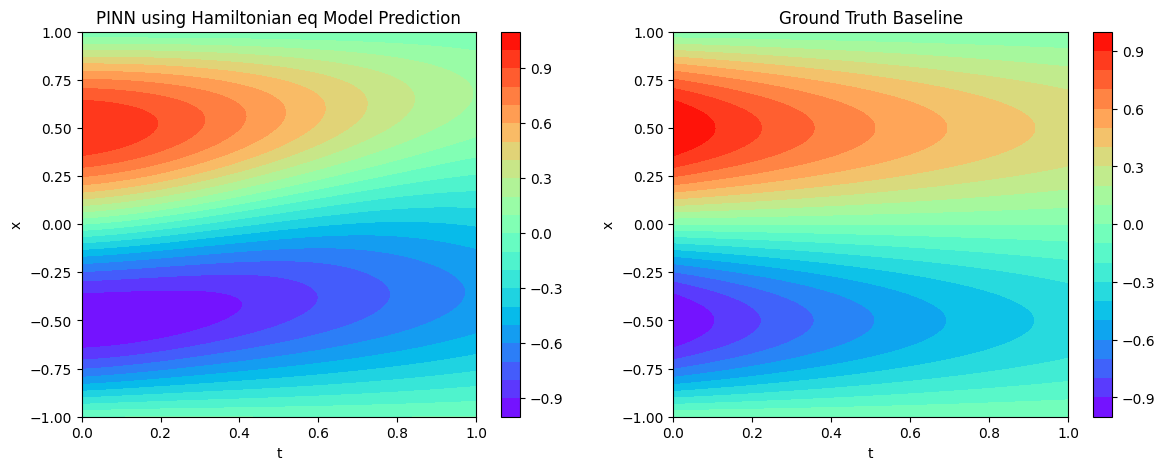

In [10]:
# --- Safe Plot Unpacking ---
arr_x1 = X_test[:, 0].reshape(total_points_x, total_points_t).detach().cpu().numpy()
arr_T1 = X_test[:, 1].reshape(total_points_x, total_points_t).detach().cpu().numpy()
arr_y1 = y1.reshape(total_points_x, total_points_t).detach().cpu().numpy()

# Safe CPU conversion for the meshgrid tensors
X_cpu = X.detach().cpu().numpy()
T_cpu = T.detach().cpu().numpy()
y_real_cpu = y_real.detach().cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PINN Model Prediction
cp1 = ax[0].contourf(arr_T1, arr_x1, arr_y1, 20, cmap="rainbow")
fig.colorbar(cp1, ax=ax[0])
ax[0].set_title("PINN using Hamiltonian eq Model Prediction")
ax[0].set_xlabel("t")
ax[0].set_ylabel("x")

# Plot 2: Ground Truth Baseline (FIXED)
cp2 = ax[1].contourf(T_cpu, X_cpu, y_real_cpu, 20, cmap="rainbow")
fig.colorbar(cp2, ax=ax[1])
ax[1].set_title("Ground Truth Baseline")
ax[1].set_xlabel("t")
ax[1].set_ylabel("x")

plt.show()

In [11]:
# 1. Define the point you want to predict (x, t)
x_new = 0.5
t_new = 0.0001

# 2. Convert to a PyTorch tensor with the correct layout [1, 2]
# The input matrix must match the structure the model expects: [[x, t]]
point = torch.tensor([[x_new, t_new]], dtype=torch.float32).to(device)

# 3. Put the model in evaluation mode and predict
PINN.eval() 
with torch.no_grad(): # Tells PyTorch not to waste memory tracking gradients
    prediction = PINN(point)

# 4. Extract the raw scalar value
y_predicted = prediction.item()

# 5. Compare with the analytical ground truth
y_true = f_real(torch.tensor(x_new), torch.tensor(t_new)).item()

print(f"Prediction at (x={x_new}, t={t_new}):")
print(f"-> PINN Estimated y: {y_predicted:.6f}")
print(f"-> True Analytical y: {y_true:.6f}")
print(f"-> Absolute Error:    {abs(y_predicted - y_true):.6f}")

Prediction at (x=0.5, t=0.0001):
-> PINN Estimated y: 1.000246
-> True Analytical y: 0.999900
-> Absolute Error:    0.000346
